In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_context("notebook")

import warnings
warnings.filterwarnings("ignore")

In [2]:
import kagglehub

path = kagglehub.dataset_download("harshshinde8/movies-csv")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Welcome\.cache\kagglehub\datasets\harshshinde8\movies-csv\versions\1


In [3]:
import os
import pandas as pd

dataset_path = path

# Auto-detect CSV file
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

if csv_files:
    file_path = os.path.join(dataset_path, csv_files[0])
    df = pd.read_csv(file_path)
    print("✅ Loaded:", csv_files[0])
else:
    print("❌ No CSV file found")

df.head()

✅ Loaded: movies.csv


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.info()

Shape: (4803, 24)

Columns: ['index', 'budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'cast', 'crew', 'director']
<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   str    
 3   homepage              1712 non-null   str    
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   str    
 6   original_language     4803 non-null   str    
 7   original_title        4803 non-null   str    
 8   overview              4800 non-null   str 

In [5]:
# 1. Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("🔍 Missing Values:\n", missing)

# 2. Detect rating column dynamically
possible_rating_cols = ['rating', 'Rating', 'imdb_score', 'vote_average', 'score']

rating_col = next((col for col in possible_rating_cols if col in df.columns), None)

if rating_col:
    print(f"✅ Using '{rating_col}' as rating column")

    # Rename to standard name (clean pipeline)
    df.rename(columns={rating_col: 'rating'}, inplace=True)

    # Drop rows where rating is missing
    df = df.dropna(subset=['rating'])

else:
    print("⚠️ No rating column found. Skipping rating-based cleaning.")

# 3. Fill remaining missing values
df = df.ffill()   # forward fill (modern replacement of fillna(method='ffill'))

# 4. Remove duplicates
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"🧹 Removed {before - after} duplicate rows")

# 5. Final shape
print("📊 Cleaned Data Shape:", df.shape)

🔍 Missing Values:
 homepage                3091
tagline                  844
keywords                 412
cast                      43
director                  30
genres                    28
overview                   3
runtime                    2
release_date               1
original_title             0
id                         0
index                      0
budget                     0
original_language          0
production_countries       0
popularity                 0
spoken_languages           0
revenue                    0
production_companies       0
status                     0
vote_average               0
title                      0
vote_count                 0
crew                       0
dtype: int64
✅ Using 'vote_average' as rating column
🧹 Removed 0 duplicate rows
📊 Cleaned Data Shape: (4803, 24)


In [6]:
# Example: Extract year if column exists
if 'release_date' in df.columns:
    df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

In [7]:
mean_rating = df['rating'].mean()
median_rating = df['rating'].median()
mode_rating = df['rating'].mode()[0]

print(f"Mean Rating: {mean_rating:.2f}")
print(f"Median Rating: {median_rating:.2f}")
print(f"Mode Rating: {mode_rating:.2f}")

Mean Rating: 6.09
Median Rating: 6.20
Mode Rating: 6.00


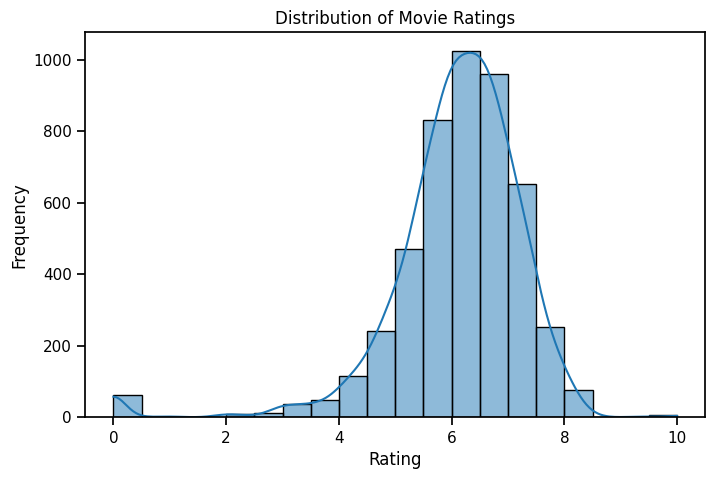

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20, kde=True)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

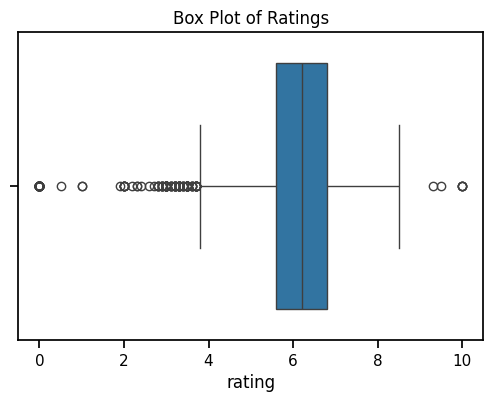

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['rating'])

plt.title("Box Plot of Ratings")
plt.show()

In [10]:
top_movies = df.sort_values(by='rating', ascending=False).head(10)

top_movies[['title', 'rating']]

,title,rating
4662,Little Big Top,10.0
3519,Stiff Upper Lips,10.0
4045,"Dancer, Texas Pop. 81",10.0
4247,Me You and Five Bucks,10.0
3992,Sardaarji,9.5
2386,One Man's Hero,9.3
1881,The Shawshank Redemption,8.5
2970,There Goes My Baby,8.5
3337,The Godfather,8.4
2796,The Prisoner of Zenda,8.4


In [11]:
if 'genre' in df.columns:
    genre_avg = df.groupby('genre')['rating'].mean().sort_values(ascending=False)

    plt.figure(figsize=(10,5))
    genre_avg.head(10).plot(kind='bar')

    plt.title("Top Genres by Average Rating")
    plt.ylabel("Average Rating")
    plt.show()

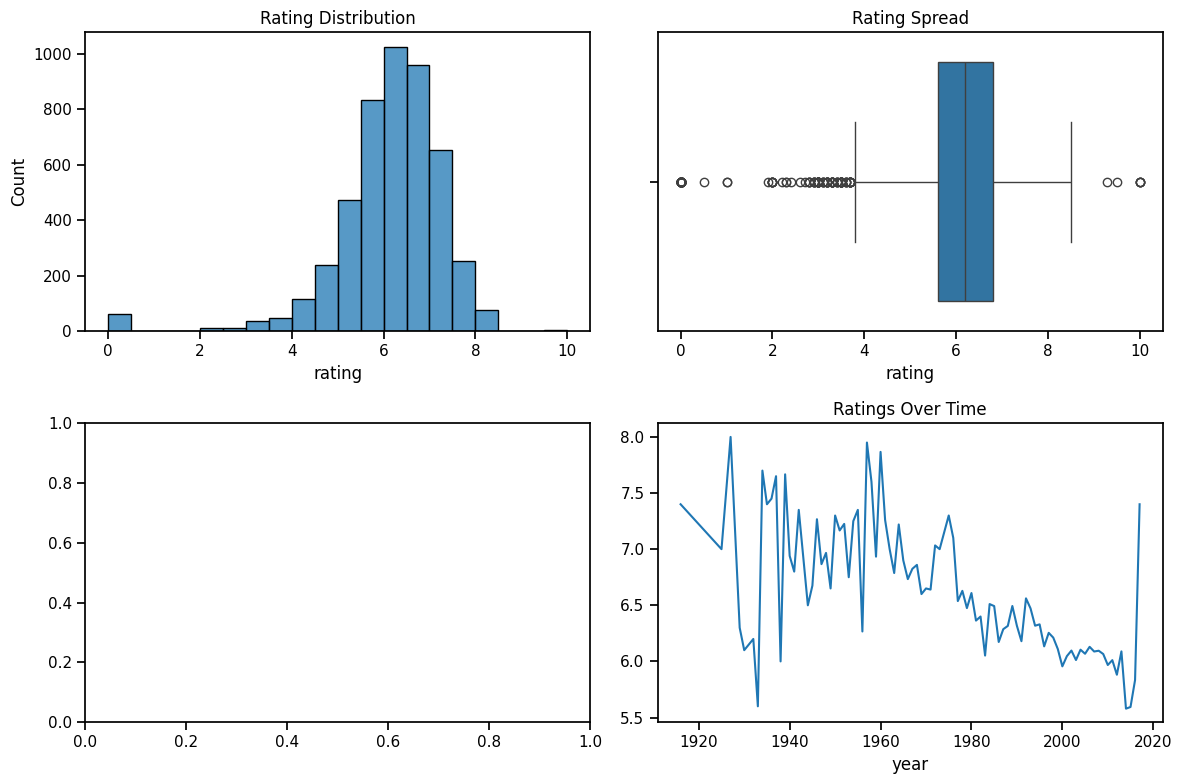

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Histogram
sns.histplot(df['rating'], bins=20, ax=axes[0,0])
axes[0,0].set_title("Rating Distribution")

# Boxplot
sns.boxplot(x=df['rating'], ax=axes[0,1])
axes[0,1].set_title("Rating Spread")

# Top Genres
if 'genre' in df.columns:
    genre_avg.head(5).plot(kind='bar', ax=axes[1,0])
    axes[1,0].set_title("Top Genres")

# Ratings by Year (if exists)
if 'year' in df.columns:
    df.groupby('year')['rating'].mean().plot(ax=axes[1,1])
    axes[1,1].set_title("Ratings Over Time")

plt.tight_layout()
plt.show()